In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

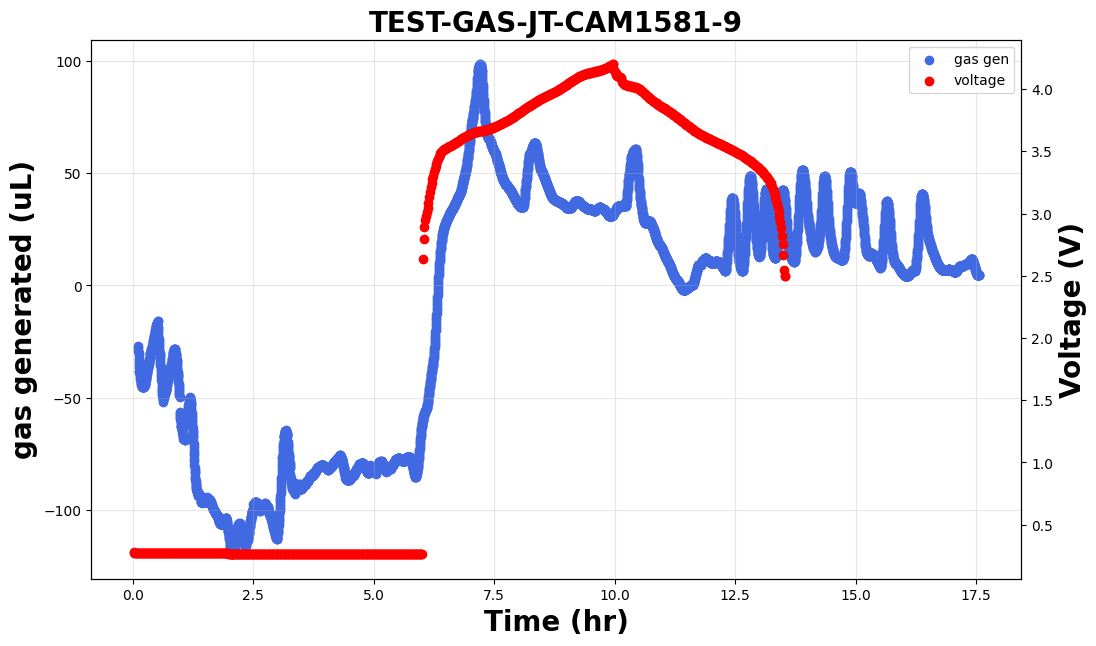

In [12]:
# data files
gas = r""
volt = r""

# name that plot will be saved under is pulled from Arbin file name
name = os.path.splitext(os.path.basename(volt))[0]
parts = name.split('_')
save = parts[0]

# read data files
dfweight = pd.read_csv(gas)
dfvoltage = pd.read_excel(volt, sheet_name=1)

# extract columns
weight_x = pd.to_numeric(dfweight.iloc[:,1], errors='coerce').to_numpy()
weight_y = pd.to_numeric(dfweight.iloc[:,2], errors='coerce').to_numpy()
volt_x = pd.to_numeric(dfvoltage['Test Time (s)'], errors='coerce').to_numpy()
volty = pd.to_numeric(dfvoltage['Voltage (V)'], errors='coerce').to_numpy()

# unit conversions
weightx = weight_x / (1000 * 3600)           # ms to hr
weighty = (weight_y[0] - weight_y) / 0.87    # apparent weight to volume of gas generated
voltx = volt_x / 3600                        # seconds to hours

# smooth the data from load cell
rolling_mean = pd.Series(weighty).rolling(window=40).mean().to_numpy()

# --- plotting with two y-axes ---
fig, ax1 = plt.subplots(figsize=(12, 7))

# Left axis: weight
ax1.scatter(weightx, rolling_mean, marker='o', color='royalblue', label='gas gen')
ax1.set_xlabel('Time (hr)', fontweight='bold', fontsize=20)
ax1.set_ylabel('gas generated (uL)', fontweight='bold', fontsize=20)

# Right axis: voltage
ax2 = ax1.twinx()
ax2.scatter(voltx, volty, marker='o', color='red', label='voltage')
ax2.set_ylabel('Voltage (V)', fontweight='bold', fontsize=20)

# Optional: make it easier to read
ax1.grid(True, alpha=0.3)
plt.title(f'{save}', fontweight='bold', fontsize=20)

# legend
# Combine legends from both axes
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

ax1.legend(h1 + h2, l1 + l2)

plt.savefig(f'{save}', dpi=200)

plt.show()

In [4]:
print(type(volt_x))
print(volt_x[:5])

<class 'numpy.ndarray'>
['03/23/2026 12:50:57.013' '03/23/2026 12:51:57.014'
 '03/23/2026 12:52:57.013' '03/23/2026 12:53:57.013'
 '03/23/2026 12:54:57.013']
